<a href="https://colab.research.google.com/github/ece-mdarifanzum/DATA-ANALYSIS-WITH-PYTHON/blob/main/OCR_of_Handwritten_digits_%7C_OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2

In [7]:
image =cv2.imread('https://media.geeksforgeeks.org/wp-content/uploads/20200324181633/digits1.png')

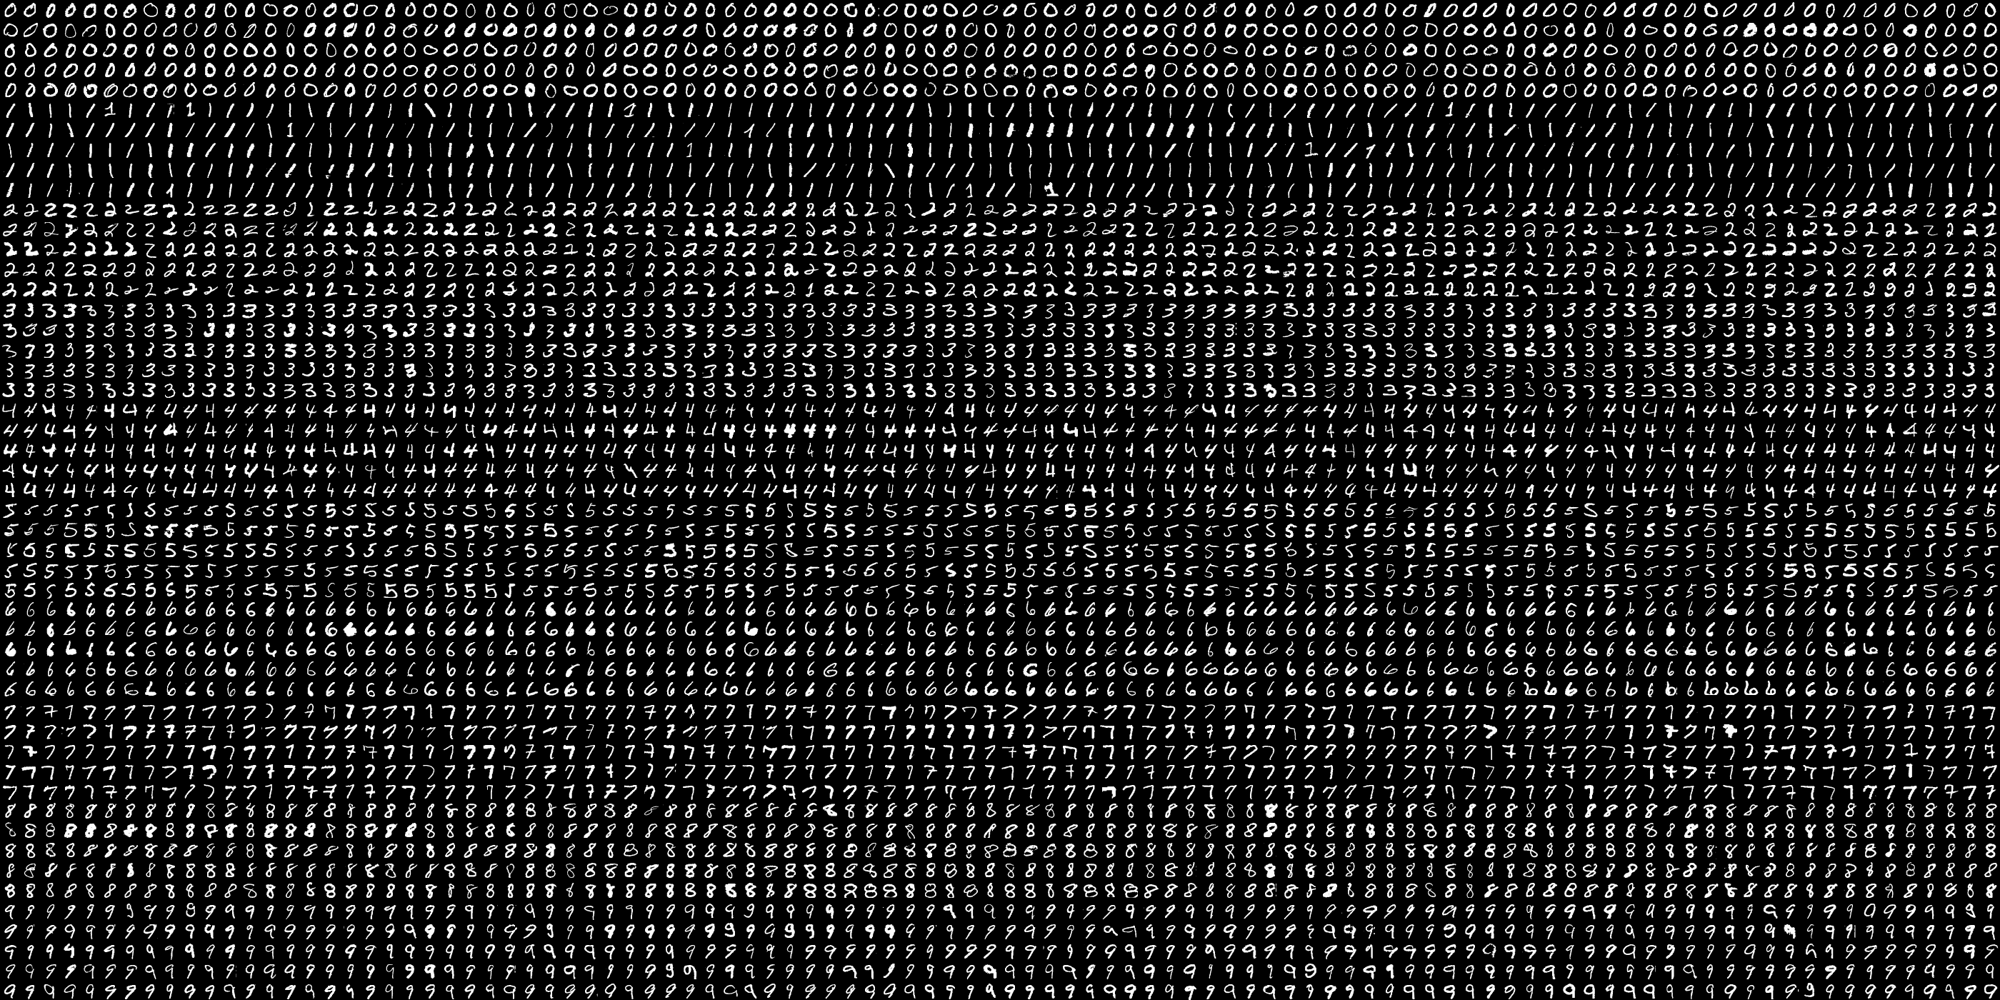

In [10]:
import requests
from google.colab.patches import cv2_imshow
import numpy as np
import cv2

image_url = 'https://media.geeksforgeeks.org/wp-content/uploads/20200324181633/digits1.png'

image_is_empty_or_not_defined = False
try:
    if 'image' not in locals() and 'image' not in globals():
        image_is_empty_or_not_defined = True
    elif image is None or image.size == 0:
        image_is_empty_or_not_defined = True
except NameError:
    image_is_empty_or_not_defined = True


if image_is_empty_or_not_defined:
    print("Image not loaded correctly from previous cell. Attempting to download and load it here.")
    try:
        response = requests.get(image_url, stream=True)
        response.raise_for_status()
        image_array = np.asarray(bytearray(response.raw.read()), dtype=np.uint8)
        image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

        if image is None or image.size == 0:
            print("Error: Image could not be loaded even after download attempt in this cell.")
            image = np.zeros((100, 100, 3), dtype=np.uint8)
    except Exception as e:
        print(f"Error downloading or decoding image: {e}")
        image = np.zeros((100, 100, 3), dtype=np.uint8)

if image is not None and image.size > 0:
    gray_img=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    cv2_imshow(gray_img)
else:
    print("Cannot process or display: Image is still empty or invalid.")

In [11]:
# We will divide the image
# into 5000 small dimensions
# of size 20x20
divisions = list(np.hsplit(i,100) for i in np.vsplit(gray_img,50))

In [12]:
# We will divide the image
# into 5000 small dimensions
# of size 20x20
divisions = list(np.hsplit(i,100) for i in np.vsplit(gray_img,50))

In [13]:
#convert into numpy array
#of size (50,100,20.20)
NP_array=np.array(divisions)

In [14]:
# Preparing train_data
# and test_data.
# Size will be (2500,20x20)
train_data = NP_array[:,:50].reshape(-1,400).astype(np.float32)

# Size will be (2500,20x20)
test_data = NP_array[:,50:100].reshape(-1,400).astype(np.float32)

# Create 10 different labels
# for each type of digit
k = np.arange(10)
train_labels = np.repeat(k,250)[:,np.newaxis]
test_labels = np.repeat(k,250)[:,np.newaxis]

# Initiate kNN classifier
knn = cv2.ml.KNearest_create()

# perform training of data
knn.train(train_data,
		cv2.ml.ROW_SAMPLE,
		train_labels)

# obtain the output from the
# classifier by specifying the
# number of neighbors.
ret, output ,neighbours, distance = knn.findNearest(test_data, k = 3)

# Check the performance and
# accuracy of the classifier.
# Compare the output with test_labels
# to find out how many are wrong.
matched = output==test_labels
correct_OP = np.count_nonzero(matched)

#Calculate the accuracy.
accuracy = (correct_OP*100.0)/(output.size)

# Display accuracy.
print(accuracy)

91.64
